In [6]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC

In [16]:

warnings.filterwarnings('ignore')


df = pd.read_csv("Dataset.csv")
print("--- Dataset Info ---")
print(f"Number of Samples: {df.shape[0]}")
print(f"Number of Features (Before Preprocessing): {X.shape[1]}")
print("\nTarget Distribution (Classification):")
print(y_clf.value_counts())
print("-" * 20)

target_reg = 'Final_Score_Regression'
target_clf = 'Performance_Level_Classification'


X = df.drop(columns=[target_reg, target_clf, 'Random_Noise_Feature']) 
y_reg = df[target_reg]
y_clf = df[target_clf]

--- Dataset Info ---
Number of Samples: 1000
Number of Features (Before Preprocessing): 10

Target Distribution (Classification):
Performance_Level_Classification
Medium    545
Low       253
High      202
Name: count, dtype: int64
--------------------


In [8]:

X = X.fillna(X.mean())


encoder = LabelEncoder()
y_clf_encoded = encoder.fit_transform(y_clf)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kf = KFold(n_splits=5, shuffle=True, random_state=42)

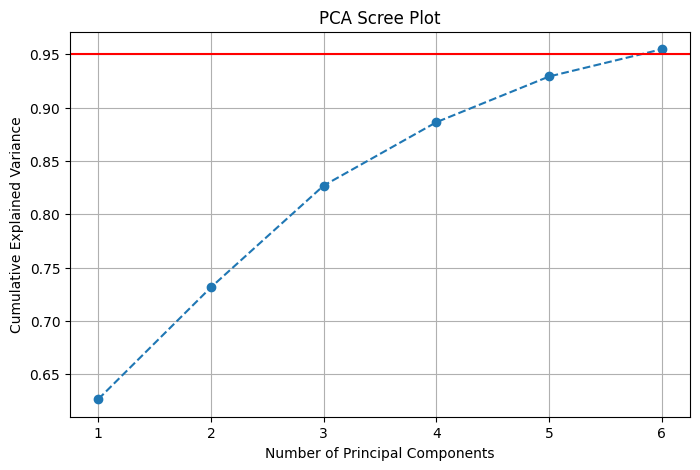

In [15]:


# Plot Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('PCA Scree Plot')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.grid(True)
plt.show()

In [10]:

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

explained_var = np.sum(pca.explained_variance_ratio_) * 100


table1_data = {
    "Components Chosen": [pca.n_components_],
    "Explained Variance (%)": [f"{explained_var:.2f}%"],
    "Justification": ["Retained 95% variance to reduce dimensionality while keeping most of the information, mitigating multicollinearity."]
}
df_table1 = pd.DataFrame(table1_data)

print("\n" + "="*50)
print("TABLE 1: PCA Summary")
print("="*50)
print(df_table1.to_markdown(index=False))


TABLE 1: PCA Summary
|   Components Chosen | Explained Variance (%)   | Justification                                                                                                       |
|--------------------:|:-------------------------|:--------------------------------------------------------------------------------------------------------------------|
|                   6 | 95.48%                   | Retained 95% variance to reduce dimensionality while keeping most of the information, mitigating multicollinearity. |


In [11]:
def get_observation(metric, no_pca, with_pca):

    if metric == "MSE":
        diff = no_pca - with_pca 
    else:
        diff = with_pca - no_pca 
        
    if diff > 0.05: return "Significant Improvement"
    elif diff > 0.01: return "Slight Improvement"
    elif diff < -0.05: return "Significant Decline"
    elif diff < -0.01: return "Slight Decline"
    else: return "Relatively Unchanged"

In [12]:

reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
}

table2_rows = []

for model_name, model in reg_models.items():
   
    mse_no = -cross_val_score(model, X_scaled, y_reg, cv=kf, scoring='neg_mean_squared_error').mean()
    mse_pca = -cross_val_score(model, X_pca, y_reg, cv=kf, scoring='neg_mean_squared_error').mean()
    table2_rows.append({
        "Model": model_name, "Metric": "MSE", 
        "Fold Avg (No-PCA)": round(mse_no, 4), "Fold Avg (With-PCA)": round(mse_pca, 4),
        "Observation": get_observation("MSE", mse_no, mse_pca)
    })
    
 
    r2_no = cross_val_score(model, X_scaled, y_reg, cv=kf, scoring='r2').mean()
    r2_pca = cross_val_score(model, X_pca, y_reg, cv=kf, scoring='r2').mean()
    table2_rows.append({
        "Model": model_name, "Metric": "R-squared", 
        "Fold Avg (No-PCA)": round(r2_no, 4), "Fold Avg (With-PCA)": round(r2_pca, 4),
        "Observation": get_observation("R2", r2_no, r2_pca)
    })

df_table2 = pd.DataFrame(table2_rows)

print("\n\n" + "="*80)
print("TABLE 2: 5-Fold CV Results - Regression")
print("="*80)
print(df_table2.to_markdown(index=False))



TABLE 2: 5-Fold CV Results - Regression
| Model             | Metric    |   Fold Avg (No-PCA) |   Fold Avg (With-PCA) | Observation          |
|:------------------|:----------|--------------------:|----------------------:|:---------------------|
| Linear Regression | MSE       |             26.2188 |               26.2118 | Relatively Unchanged |
| Linear Regression | R-squared |              0.7481 |                0.7482 | Relatively Unchanged |
| Random Forest     | MSE       |             28.8752 |               28.9282 | Significant Decline  |
| Random Forest     | R-squared |              0.723  |                0.7221 | Relatively Unchanged |


In [13]:

clf_models = {
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000),
    "SVM": SVC(kernel='rbf', C=1.0, gamma='scale')
}

table3_rows = []

for model_name, model in clf_models.items():
   
    acc_no = cross_val_score(model, X_scaled, y_clf_encoded, cv=kf, scoring='accuracy').mean()
    acc_pca = cross_val_score(model, X_pca, y_clf_encoded, cv=kf, scoring='accuracy').mean()
    table3_rows.append({
        "Model": model_name, "Metric": "Accuracy", 
        "Fold Avg (No-PCA)": round(acc_no, 4), "Fold Avg (With-PCA)": round(acc_pca, 4),
        "Observation": get_observation("Accuracy", acc_no, acc_pca)
    })
    
    
    f1_no = cross_val_score(model, X_scaled, y_clf_encoded, cv=kf, scoring='f1_weighted').mean()
    f1_pca = cross_val_score(model, X_pca, y_clf_encoded, cv=kf, scoring='f1_weighted').mean()
    table3_rows.append({
        "Model": model_name, "Metric": "F1-score", 
        "Fold Avg (No-PCA)": round(f1_no, 4), "Fold Avg (With-PCA)": round(f1_pca, 4),
        "Observation": get_observation("F1", f1_no, f1_pca)
    })


df_table3 = pd.DataFrame(table3_rows)

print("\n\n" + "="*80)
print("TABLE 3: 5-Fold CV Results - Classification")
print("="*80)
print(df_table3.to_markdown(index=False))



TABLE 3: 5-Fold CV Results - Classification
| Model               | Metric   |   Fold Avg (No-PCA) |   Fold Avg (With-PCA) | Observation          |
|:--------------------|:---------|--------------------:|----------------------:|:---------------------|
| Logistic Regression | Accuracy |              0.741  |                0.749  | Relatively Unchanged |
| Logistic Regression | F1-score |              0.7384 |                0.7471 | Relatively Unchanged |
| SVM                 | Accuracy |              0.741  |                0.742  | Relatively Unchanged |
| SVM                 | F1-score |              0.7352 |                0.7359 | Relatively Unchanged |
